In [2]:
import os
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler

from config.paths import DATA_DIR, PAPER_FIGURES_DIR
from config.test_calibration_validation import required_start

# matplotlib config
import matplotlib.pyplot as plt
Paper_width = 6.30045
plt.style.use("paper_style.mplstyle")


In [3]:
first_training_date = required_start

# load Load
Load = pd.read_csv(os.path.join(DATA_DIR, "Load", "Load_2018-2020.csv"), parse_dates = ['Time from'], index_col=0)
Load.index = pd.to_datetime(Load.index)
Load = Load[Load.index >= first_training_date]

# res generation
gen = pd.read_csv(os.path.join(DATA_DIR, "Generation", "Generation_2018-2020.csv"), index_col=0)
gen.index = pd.to_datetime(gen.index)
gen = gen[gen.index >= first_training_date]


Below is a standalone weather scenarios generator used just for the idea illustration (similar code can be found in the cSVR model implementation)

In [4]:
date_fore = datetime(year=2020,month=12,day=31)
forecasting_horizon = 31
shift_trade = 6
shift = 61 + 15
transform = False

historical_scenarios_all_deliveries = []
historical_actual_all_deliveries = []
historical_onedelta_all_deliveries = []

for delivery in range(96):
    trade_time = delivery * 3 + 8 * 12 - shift_trade

    historical_scenarios_all_exog_idxs = []
    historical_actual_all_exog_idxs = []
    historical_onedelta_all_exog_idxs = []

    for exog_idx, exog_df in enumerate([Load.copy(deep=True), gen.copy(deep=True)]):

        historical_scenarios_all_fut_interv_con = []
        historical_scenarios_all_fut_interv_spv = []
        historical_scenarios_all_fut_interv_wnd = []

        historical_actual_all_fut_interv_con = []
        historical_actual_all_fut_interv_spv = []
        historical_actual_all_fut_interv_wnd = []

        historical_onedelta_all_fut_interv_con = []
        historical_onedelta_all_fut_interv_spv = []
        historical_onedelta_all_fut_interv_wnd = []

        exog_avail_mins = 5*(trade_time - forecasting_horizon) # 61mins to account for data avail

        datetime_avail = (pd.to_datetime(date_fore) - timedelta(days=1)).replace(hour=16) + timedelta(minutes=exog_avail_mins - shift)

        last_trade_time = (pd.to_datetime(date_fore) - timedelta(days=1)).replace(hour=16) + timedelta(minutes=5*(trade_time-1))

        exog_df = exog_df[exog_df.index <= last_trade_time]

        exog_last_info = exog_df[(exog_df.index.hour == datetime_avail.hour) & (exog_df.index.minute == datetime_avail.minute//15 * 15)]

        for future_interval in range(int(np.ceil(forecasting_horizon/3)))[::-1]:

            datetime_max_required_fore = (pd.to_datetime(date_fore) - timedelta(days=1)).replace(hour=16) + timedelta(minutes=5*(trade_time-1) - future_interval*15)

            exog_fore = exog_df[(exog_df.index.hour == datetime_max_required_fore.hour) & (exog_df.index.minute == datetime_max_required_fore.minute//15 * 15)]

            if datetime_max_required_fore.date() > datetime_avail.date(): # handle 2 different dates of avail and fore by shifting exog last info forward
                exog_fore = exog_fore.iloc[1:]

            exog_fore_info = 1

            hist_scenarios_similarity_scaler = MinMaxScaler() # we need to have the same min and max values and we need to have positive values only

            if exog_idx == 0:
                delta_known = exog_last_info['Actual'] - exog_last_info['Forecast']
                delta_fore = exog_fore['Actual'] - exog_fore['Forecast']
                if transform:
                    deltas_delta = hist_scenarios_similarity_scaler.fit_transform((delta_known.values - delta_fore.values).reshape(-1, 1))
                else:
                    deltas_delta = delta_known.values - delta_fore.values

                historical_scenarios_all_fut_interv_con.append(deltas_delta)
                historical_actual_all_fut_interv_con.append(exog_fore['Actual'])
                historical_onedelta_all_fut_interv_con.append(delta_fore)

            elif exog_idx == 1:
                delta_known = exog_last_info['SPV'] - exog_last_info['SPV DA']
                delta_fore = exog_fore['SPV'] - exog_fore['SPV DA']
                if transform:
                    deltas_delta = hist_scenarios_similarity_scaler.fit_transform((delta_known.values - delta_fore.values).reshape(-1, 1))
                else:
                    deltas_delta = delta_known.values - delta_fore.values

                historical_scenarios_all_fut_interv_spv.append(deltas_delta)
                historical_actual_all_fut_interv_spv.append(exog_fore['SPV'])
                historical_onedelta_all_fut_interv_spv.append(delta_fore)

                delta_known = exog_last_info['W'] - exog_last_info['W DA']
                delta_fore = exog_fore['W'] - exog_fore['W DA']
                if transform:
                    deltas_delta = hist_scenarios_similarity_scaler.fit_transform((delta_known.values - delta_fore.values).reshape(-1, 1))
                else:
                    deltas_delta = delta_known.values - delta_fore.values

                historical_scenarios_all_fut_interv_wnd.append(deltas_delta)
                historical_actual_all_fut_interv_wnd.append(exog_fore['W'])
                historical_onedelta_all_fut_interv_wnd.append(delta_fore)

        if exog_idx == 0: 
            historical_scenarios_all_exog_idxs.append(historical_scenarios_all_fut_interv_con)
            historical_actual_all_exog_idxs.append(historical_actual_all_fut_interv_con)
            historical_onedelta_all_exog_idxs.append(historical_onedelta_all_fut_interv_con)
        elif exog_idx == 1:
            historical_scenarios_all_exog_idxs.append(historical_scenarios_all_fut_interv_spv)
            historical_scenarios_all_exog_idxs.append(historical_scenarios_all_fut_interv_wnd)

            historical_actual_all_exog_idxs.append(historical_actual_all_fut_interv_spv)
            historical_actual_all_exog_idxs.append(historical_actual_all_fut_interv_wnd)

            historical_onedelta_all_exog_idxs.append(historical_onedelta_all_fut_interv_spv)
            historical_onedelta_all_exog_idxs.append(historical_onedelta_all_fut_interv_wnd)

    historical_scenarios_all_deliveries.append(historical_scenarios_all_exog_idxs)
    historical_actual_all_deliveries.append(historical_actual_all_exog_idxs)
    historical_onedelta_all_deliveries.append(historical_onedelta_all_exog_idxs)


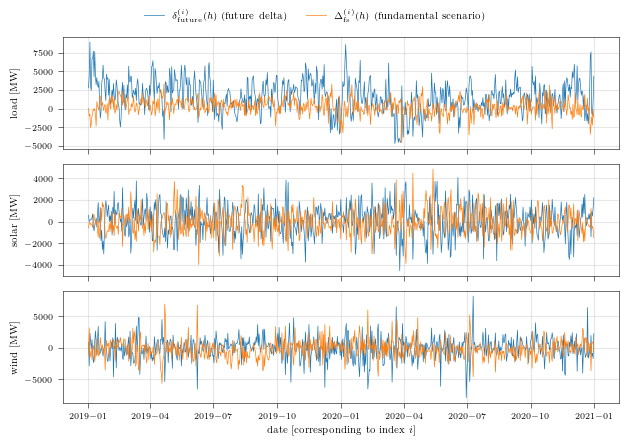

In [5]:
fig, ax = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(Paper_width, 0.7 * Paper_width),
    sharex=True
)

cases = [0, 1, 2]
labels = ['load [MW]', 'solar [MW]', 'wind [MW]']

for i, case in enumerate(cases):
    scenarios = historical_scenarios_all_deliveries[56][case][10]
    actual = historical_actual_all_deliveries[56][case][10]
    onedelta = historical_onedelta_all_deliveries[56][case][10]

    x = exog_last_info.index.date

    ax[i].plot(x, onedelta, label="$\delta^{(i)}_{\mathrm{future}}(h)$ (future delta)", lw=0.5)
    ax[i].plot(x, scenarios, label="$\Delta^{(i)}_{\mathrm{fs}}(h)$ (fundamental scenario)", lw=0.5)

    ax[i].grid(True, alpha=0.3)

    ax[i].set_ylabel(labels[i])

# Axis labels
ax[-1].set_xlabel("date [corresponding to index $i$]")

# Single legend for entire figure
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(os.path.join(PAPER_FIGURES_DIR, "weather_scenarios_choice_illustrated.pdf"), bbox_inches="tight")
plt.show()


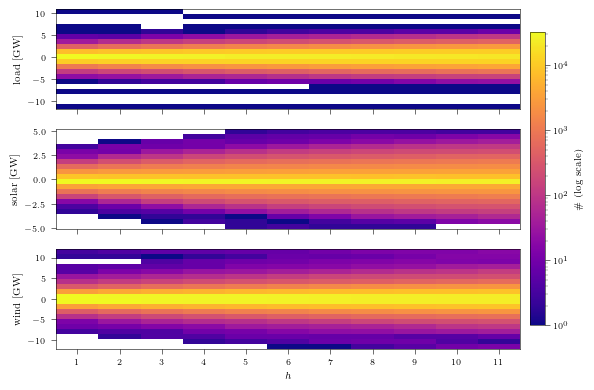

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

num_bins = 20

techs = ['con', 'spv', 'wnd']
labels = ['load', 'solar', 'wind']

fig, ax = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(Paper_width, 0.7 * Paper_width),
    sharey=False,
    sharex=True
)

for tech_idx, tech in zip(range(3), techs):

    all_values = []
    for delivery in range(len(historical_scenarios_all_deliveries)):
        for horizon in range(len(historical_scenarios_all_deliveries[0][tech_idx])):
            all_values.extend(
                historical_scenarios_all_deliveries[delivery][tech_idx][horizon]
            )

    global_min, global_max = min(all_values), max(all_values)
    bin_edges = np.linspace(global_min, global_max, num_bins + 1)

    # build histogram matrix
    hist_per_horizon = []
    for horizon in range(11):
        agg = []
        for delivery in range(96):
            agg.extend(
                historical_scenarios_all_deliveries[delivery][tech_idx][horizon]
            )
        bins_vals, _ = np.histogram(agg, bins=bin_edges)
        hist_per_horizon.append(bins_vals)

    # shape: (11 horizons, num_bins)
    H = np.array(hist_per_horizon)

    # mesh
    X = np.arange(0.5, 11.5 + 1, 1)   # 12 edges → 11 bins
    Y = bin_edges
    Z = H.T                # (num_bins, 11)

    pcm = ax[tech_idx].pcolormesh(
        X,
        Y / 1000,
        Z,
        cmap='plasma',
        norm=LogNorm(vmin=max(Z.min(), 1), vmax=Z.max())
    )

    ax[tech_idx].set_ylabel(
        f"{labels[tech_idx]} [GW]",
    )

    ax[tech_idx].tick_params(axis='x')
    ax[tech_idx].tick_params(axis='y')

cbar = fig.colorbar(
    pcm,                 # any one of the QuadMesh objects
    ax=ax,             # list/array of all subplots
    orientation='vertical',
    fraction=0.03,
    pad=0.02
)
cbar.ax.tick_params()
cbar.set_label('\# (log scale)')
ax[tech_idx].set_xlabel('$h$')
ax[tech_idx].set_xticks(np.arange(1, 12))

plt.savefig(os.path.join(PAPER_FIGURES_DIR, "weather_scenarios_analysis.pdf"), bbox_inches="tight")

plt.show()
